# 12D_model_final_report.ipynb — Informe final de resultados de modelado

Este notebook consolida los resultados de:

```text
12_model_training_lightgbm.ipynb
12B_model_training_xgboost_risk.ipynb
12C_model_comparison_lightgbm_xgboost.ipynb
```

Objetivo:

```text
Generar tablas, gráficos y texto listo para documentar en la memoria del TFM.
```

Modelos resumidos:

```text
1. Persistence baseline
2. LightGBMRegressor para predicción de altura significativa de ola
3. XGBClassifier para clasificación directa de riesgo marítimo
```

Decisión metodológica esperada:

```text
- LightGBMRegressor como modelo principal para hs futura.
- XGBClassifier como modelo recomendado para riesgo marítimo operativo si se prioriza detectar riesgo alto/extremo.
```

Salidas:

```text
gold/model_results/final_report/
```

## Celda 0 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Celda 1 — Instalar librerías

In [2]:
!pip -q install pandas numpy pyarrow matplotlib scikit-learn

## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
GOLD_DIR = BASE_DIR / "gold"

LGBM_DIR = GOLD_DIR / "model_results" / "lightgbm"
XGB_DIR = GOLD_DIR / "model_results" / "xgboost_risk"
COMPARISON_DIR = GOLD_DIR / "model_results" / "model_comparison"
OUT_DIR = GOLD_DIR / "model_results" / "final_report"

OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS = [3, 6, 12, 24]
RISK_CLASSES = [0, 1, 2, 3]

RISK_CLASS_NAMES = {
    0: "Bajo",
    1: "Moderado",
    2: "Alto",
    3: "Extremo",
}

print("LGBM_DIR:", LGBM_DIR, "existe:", LGBM_DIR.exists())
print("XGB_DIR:", XGB_DIR, "existe:", XGB_DIR.exists())
print("COMPARISON_DIR:", COMPARISON_DIR, "existe:", COMPARISON_DIR.exists())
print("OUT_DIR:", OUT_DIR)

if not COMPARISON_DIR.exists():
    raise FileNotFoundError("No existe gold/model_results/model_comparison/. Ejecuta primero 12C_model_comparison_lightgbm_xgboost.ipynb.")

LGBM_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm existe: True
XGB_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/xgboost_risk existe: True
COMPARISON_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/model_comparison existe: True
OUT_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report


## Celda 3 — Funciones auxiliares

In [4]:
def read_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {path}")
    return pd.read_csv(path)


def read_csv_optional(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def fmt_pct(value, decimals=2):
    if pd.isna(value):
        return ""
    return f"{value * 100:.{decimals}f}%"


def fmt_num(value, decimals=4):
    if pd.isna(value):
        return ""
    return f"{value:.{decimals}f}"


def save_markdown(text, path):
    path = Path(path)
    path.write_text(text, encoding="utf-8")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def add_bar_labels(ax, decimals=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=f"%.{decimals}f", fontsize=8)


def plot_lines(df, metric, title, ylabel, output_name, models_order=None):
    plt.figure(figsize=(9, 5))

    if models_order is None:
        models_order = list(df["model"].dropna().unique())

    for model_name in models_order:
        data = df[df["model"] == model_name].sort_values("horizon_hours")
        if data.empty:
            continue
        plt.plot(data["horizon_hours"], data[metric], marker="o", label=model_name)

    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=160)
    plt.show()


def plot_grouped_bars(df, metric, title, ylabel, output_name, models_order=None):
    plot_df = df.copy()

    if models_order is None:
        models_order = list(plot_df["model"].dropna().unique())

    horizons = sorted(plot_df["horizon_hours"].unique())
    x = np.arange(len(horizons))
    width = 0.8 / max(1, len(models_order))

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    for i, model_name in enumerate(models_order):
        data = (
            plot_df[plot_df["model"] == model_name]
            .set_index("horizon_hours")
            .reindex(horizons)
        )

        values = data[metric].values
        ax.bar(x + (i - (len(models_order) - 1) / 2) * width, values, width, label=model_name)

    ax.set_xticks(x)
    ax.set_xticklabels([f"+{h}h" for h in horizons])
    ax.set_xlabel("Horizonte predictivo")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=160)
    plt.show()

## Celda 4 — Cargar resultados consolidados

In [5]:
lgbm_regression = read_csv_required(COMPARISON_DIR / "lgbm_regression_metrics_recalculated.csv")
lgbm_risk = read_csv_required(COMPARISON_DIR / "lgbm_risk_metrics_recalculated.csv")
xgb_risk = read_csv_required(COMPARISON_DIR / "xgb_risk_metrics_recalculated.csv")
risk_comparison = read_csv_required(COMPARISON_DIR / "comparison_risk_metrics.csv")
model_vs_model = read_csv_required(COMPARISON_DIR / "comparison_lightgbm_vs_xgboost_test.csv")
recommendation = read_csv_required(COMPARISON_DIR / "recommendation_by_horizon.csv")
executive = read_csv_required(COMPARISON_DIR / "executive_model_comparison_summary.csv")

importance_top20 = read_csv_optional(COMPARISON_DIR / "comparison_feature_importance_top20.csv")
importance_all = read_csv_optional(COMPARISON_DIR / "comparison_feature_importance_all.csv")

print("lgbm_regression:", lgbm_regression.shape)
print("lgbm_risk:", lgbm_risk.shape)
print("xgb_risk:", xgb_risk.shape)
print("risk_comparison:", risk_comparison.shape)
print("model_vs_model:", model_vs_model.shape)
print("recommendation:", recommendation.shape)
print("executive:", executive.shape)
print("importance_top20:", importance_top20.shape)

display(lgbm_regression.head())
display(risk_comparison.head())
display(executive)

lgbm_regression: (16, 10)
lgbm_risk: (16, 25)
xgb_risk: (16, 25)
risk_comparison: (24, 25)
model_vs_model: (4, 25)
recommendation: (4, 6)
executive: (4, 13)
importance_top20: (160, 6)


,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr
0,3,target_hs_3h,val,LightGBMRegressor,87300,0.058005,0.088922,0.985683,-0.000454,0.992857
1,3,target_hs_3h,val,Persistence,87300,0.082156,0.119858,0.973988,-0.000113,0.986993
2,6,target_hs_6h,val,LightGBMRegressor,87240,0.108338,0.156252,0.955825,0.000921,0.977882
3,6,target_hs_6h,val,Persistence,87240,0.143064,0.203847,0.924815,-0.000284,0.962399
4,12,target_hs_12h,val,LightGBMRegressor,87120,0.194558,0.270941,0.867363,0.005827,0.931801


,horizon_hours,target,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_class_0,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,3,target_risk_3h,val,LightGBMRegressor_risk_derived,87300,0.948992,0.932388,0.939092,0.948916,0.952152,...,0.958456,44724,0.938131,0.936814,0.937472,23518,0.940283,0.884551,0.911566,4201
1,6,target_risk_6h,val,LightGBMRegressor_risk_derived,87240,0.901032,0.865697,0.882035,0.900684,0.922822,...,0.919255,44665,0.875386,0.879405,0.877391,23525,0.898667,0.770531,0.829681,4201
2,12,target_risk_12h,val,LightGBMRegressor_risk_derived,87120,0.822004,0.753436,0.782151,0.820672,0.882507,...,0.855925,44565,0.767152,0.790805,0.778799,23514,0.808819,0.572007,0.670106,4201
3,24,target_risk_24h,val,LightGBMRegressor_risk_derived,87120,0.715680,0.590962,0.625724,0.709848,0.842435,...,0.771610,44583,0.625610,0.682186,0.652674,23498,0.649123,0.255476,0.366650,4200
4,3,target_risk_3h,test,LightGBMRegressor_risk_derived,174135,0.944767,0.934673,0.939179,0.944729,0.941726,...,0.956700,91327,0.925868,0.927224,0.926546,43696,0.954737,0.917236,0.935611,13315


,horizon_hours,recommended_model,persistence_macro_f1,lgbm_macro_f1,xgb_macro_f1,persistence_balanced_accuracy,lgbm_balanced_accuracy,xgb_balanced_accuracy,lgbm_recall_class_3,xgb_recall_class_3,score_lgbm,score_xgb,notes
0,3,XGBClassifier_direct_risk,0.909224,0.939179,0.930576,0.909337,0.934673,0.946344,0.917236,0.958092,0.931645,0.941127,Mejor score compuesto de seguridad.
1,6,XGBClassifier_direct_risk,0.840787,0.883351,0.869121,0.841002,0.871643,0.894486,0.821012,0.895014,0.865020,0.882085,Mejor score compuesto de seguridad.
2,12,XGBClassifier_direct_risk,0.740397,0.785569,0.766844,0.740646,0.762452,0.798065,0.643482,0.744989,0.748132,0.771998,Mejor score compuesto de seguridad.
3,24,XGBClassifier_direct_risk,0.614795,0.629172,0.622502,0.614597,0.596647,0.665456,0.299902,0.597165,0.554471,0.627762,Mejor score compuesto de seguridad.


## Celda 5 — Tabla final de regresión LightGBM

In [6]:
reg_test = lgbm_regression[lgbm_regression["split"] == "test"].copy()

reg_wide = reg_test.pivot_table(
    index=["horizon_hours", "target"],
    columns="model",
    values=["mae", "rmse", "r2", "bias", "corr"],
)

display(reg_wide)

reg_summary_rows = []

for h in HORIZONS_HOURS:
    subset = reg_test[reg_test["horizon_hours"] == h]

    if subset.empty:
        continue

    lgbm_row = subset[subset["model"] == "LightGBMRegressor"].iloc[0]
    pers_row = subset[subset["model"] == "Persistence"].iloc[0]

    reg_summary_rows.append(
        {
            "horizon_hours": h,
            "model_selected_for_hs": "LightGBMRegressor",
            "mae_lightgbm": lgbm_row["mae"],
            "mae_persistence": pers_row["mae"],
            "mae_improvement_pct": (pers_row["mae"] - lgbm_row["mae"]) / pers_row["mae"] * 100 if pers_row["mae"] > 0 else np.nan,
            "rmse_lightgbm": lgbm_row["rmse"],
            "rmse_persistence": pers_row["rmse"],
            "rmse_improvement_pct": (pers_row["rmse"] - lgbm_row["rmse"]) / pers_row["rmse"] * 100 if pers_row["rmse"] > 0 else np.nan,
            "r2_lightgbm": lgbm_row["r2"],
            "r2_persistence": pers_row["r2"],
            "corr_lightgbm": lgbm_row["corr"],
            "corr_persistence": pers_row["corr"],
            "bias_lightgbm": lgbm_row["bias"],
            "bias_persistence": pers_row["bias"],
        }
    )

regression_final_summary = pd.DataFrame(reg_summary_rows)
regression_final_summary.to_csv(OUT_DIR / "table_01_regression_lightgbm_summary.csv", index=False)

display(regression_final_summary)

bias                          corr  \
model                       LightGBMRegressor Persistence LightGBMRegressor   
horizon_hours target                                                          
3             target_hs_3h          -0.000656    0.000349          0.992545   
6             target_hs_6h           0.000212    0.000729          0.978034   
12            target_hs_12h          0.000439    0.001481          0.931078   
24            target_hs_24h         -0.009273    0.001743          0.824775   

                                                      mae              \
model                       Persistence LightGBMRegressor Persistence   
horizon_hours target                                                    
3             target_hs_3h     0.987132          0.062603    0.089138   
6             target_hs_6h     0.961796          0.115955    0.155820   
12            target_hs_12h    0.896824          0.208555    0.255759   
24            target_hs_24h    0.766396          0.330201    0.387839   

                                           r2                          rmse  \
model                       LightGBMRegressor Persistence LightGBMRegressor   
horizon_hours target                                                          
3             target_hs_3h           0.984963    0.974257          0.099376   
6             target_hs_6h           0.955884    0.923556          0.170217   
12            target_hs_12h          0.865371    0.793529          0.297417   
24            target_hs_24h          0.677494    0.532749          0.460345   

                                         
model                       Persistence  
horizon_hours target                     
3             target_hs_3h     0.130027  
6             target_hs_6h     0.224067  
12            target_hs_12h    0.368320  
24            target_hs_24h    0.554102

,horizon_hours,model_selected_for_hs,mae_lightgbm,mae_persistence,mae_improvement_pct,rmse_lightgbm,rmse_persistence,rmse_improvement_pct,r2_lightgbm,r2_persistence,corr_lightgbm,corr_persistence,bias_lightgbm,bias_persistence
0,3,LightGBMRegressor,0.062603,0.089138,29.768745,0.099376,0.130027,23.572982,0.984963,0.974257,0.992545,0.987132,-0.000656,0.000349
1,6,LightGBMRegressor,0.115955,0.155820,25.584271,0.170217,0.224067,24.032863,0.955884,0.923556,0.978034,0.961796,0.000212,0.000729
2,12,LightGBMRegressor,0.208555,0.255759,18.456280,0.297417,0.368320,19.250511,0.865371,0.793529,0.931078,0.896824,0.000439,0.001481
3,24,LightGBMRegressor,0.330201,0.387839,14.861162,0.460345,0.554102,16.920505,0.677494,0.532749,0.824775,0.766396,-0.009273,0.001743


## Celda 6 — Tabla final de riesgo por modelo

In [7]:
risk_test = risk_comparison[risk_comparison["split"] == "test"].copy()

risk_summary_cols = [
    "horizon_hours",
    "model",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "recall_class_2",
    "recall_class_3",
    "f1_class_2",
    "f1_class_3",
    "support_class_2",
    "support_class_3",
]

risk_final_summary = risk_test[risk_summary_cols].copy()
risk_final_summary = risk_final_summary.sort_values(["horizon_hours", "model"])

risk_final_summary.to_csv(OUT_DIR / "table_02_risk_model_comparison_test.csv", index=False)

display(risk_final_summary)

,horizon_hours,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,recall_class_2,recall_class_3,f1_class_2,f1_class_3,support_class_2,support_class_3
4,3,LightGBMRegressor_risk_derived,0.944767,0.934673,0.939179,0.944729,0.927224,0.917236,0.926546,0.935611,43696,13315
20,3,PersistenceRisk,0.918489,0.909337,0.909224,0.918493,0.886077,0.895757,0.885843,0.895152,43696,13315
12,3,XGBClassifier_direct_risk,0.934775,0.946344,0.930576,0.935083,0.932694,0.958092,0.914476,0.930183,43696,13315
5,6,LightGBMRegressor_risk_derived,0.896803,0.871643,0.883351,0.896622,0.867681,0.821012,0.859370,0.863140,43637,13297
21,6,PersistenceRisk,0.858684,0.841002,0.840787,0.858706,0.799780,0.808152,0.799267,0.807060,43637,13297
13,6,XGBClassifier_direct_risk,0.878315,0.894486,0.869121,0.879333,0.870294,0.895014,0.837669,0.852935,43637,13297
6,12,LightGBMRegressor_risk_derived,0.814929,0.762452,0.785569,0.814217,0.771673,0.643482,0.746982,0.725889,43534,13270
22,12,PersistenceRisk,0.773001,0.740646,0.740397,0.773075,0.675036,0.666164,0.674168,0.664587,43534,13270
14,12,XGBClassifier_direct_risk,0.786606,0.798065,0.766844,0.789471,0.767906,0.744989,0.714087,0.700837,43534,13270
7,24,LightGBMRegressor_risk_derived,0.704342,0.596647,0.629172,0.698370,0.635241,0.299902,0.595484,0.422411,43489,13261


## Celda 7 — Tabla de decisión final por horizonte

In [8]:
decision_rows = []

for h in HORIZONS_HOURS:
    rec = recommendation[recommendation["horizon_hours"] == h].iloc[0]
    comp = model_vs_model[model_vs_model["horizon_hours"] == h].iloc[0]

    decision_rows.append(
        {
            "horizon_hours": h,
            "hs_model": "LightGBMRegressor",
            "risk_model_recommended": rec["recommended_model"],
            "score_lgbm": rec["score_lgbm"],
            "score_xgb": rec["score_xgb"],
            "score_delta_xgb_minus_lgbm": rec["score_delta_xgb_minus_lgbm"],
            "macro_f1_lgbm": comp["macro_f1_lgbm"],
            "macro_f1_xgb": comp["macro_f1_xgb"],
            "balanced_accuracy_lgbm": comp["balanced_accuracy_lgbm"],
            "balanced_accuracy_xgb": comp["balanced_accuracy_xgb"],
            "recall_class_3_lgbm": comp["recall_class_3_lgbm"],
            "recall_class_3_xgb": comp["recall_class_3_xgb"],
            "decision_reason": rec["reason"],
        }
    )

final_model_decision = pd.DataFrame(decision_rows)
final_model_decision.to_csv(OUT_DIR / "table_03_final_model_decision_by_horizon.csv", index=False)

display(final_model_decision)

,horizon_hours,hs_model,risk_model_recommended,score_lgbm,score_xgb,score_delta_xgb_minus_lgbm,macro_f1_lgbm,macro_f1_xgb,balanced_accuracy_lgbm,balanced_accuracy_xgb,recall_class_3_lgbm,recall_class_3_xgb,decision_reason
0,3,LightGBMRegressor,XGBClassifier_direct_risk,0.931645,0.941127,0.009482,0.939179,0.930576,0.934673,0.946344,0.917236,0.958092,Mejor score compuesto de seguridad.
1,6,LightGBMRegressor,XGBClassifier_direct_risk,0.865020,0.882085,0.017065,0.883351,0.869121,0.871643,0.894486,0.821012,0.895014,Mejor score compuesto de seguridad.
2,12,LightGBMRegressor,XGBClassifier_direct_risk,0.748132,0.771998,0.023867,0.785569,0.766844,0.762452,0.798065,0.643482,0.744989,Mejor score compuesto de seguridad.
3,24,LightGBMRegressor,XGBClassifier_direct_risk,0.554471,0.627762,0.073291,0.629172,0.622502,0.596647,0.665456,0.299902,0.597165,Mejor score compuesto de seguridad.


## Celda 8 — Gráficos finales de regresión

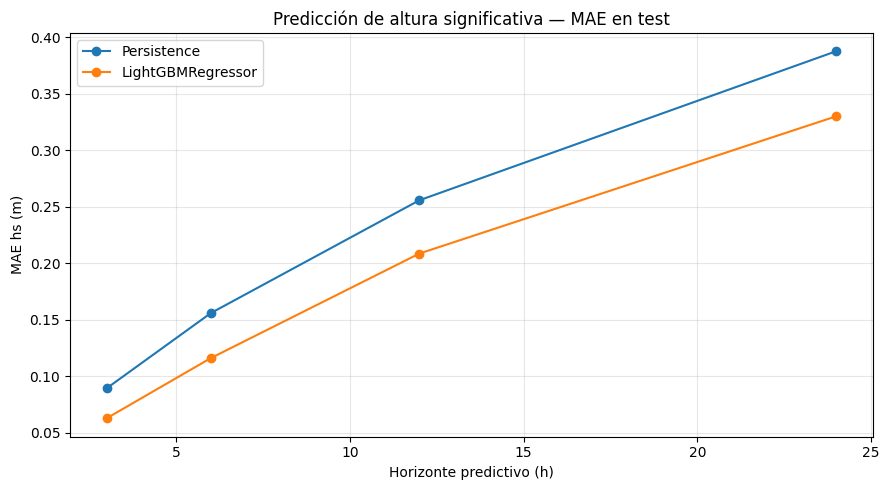

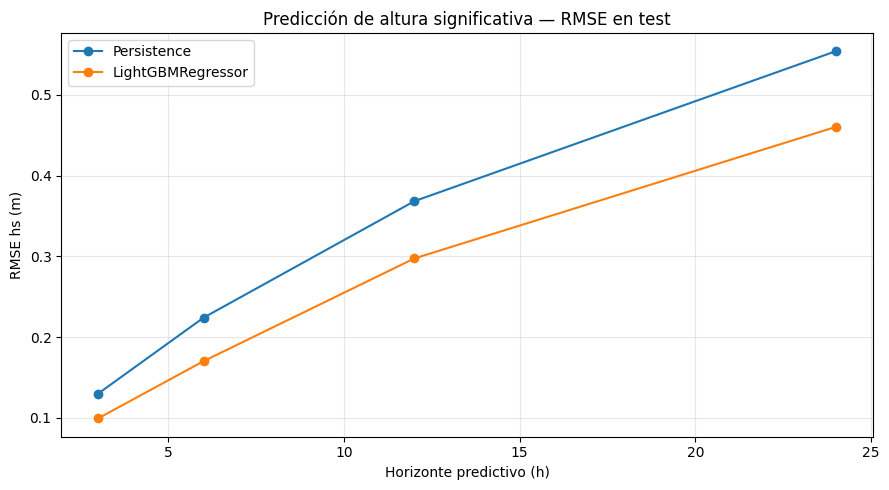

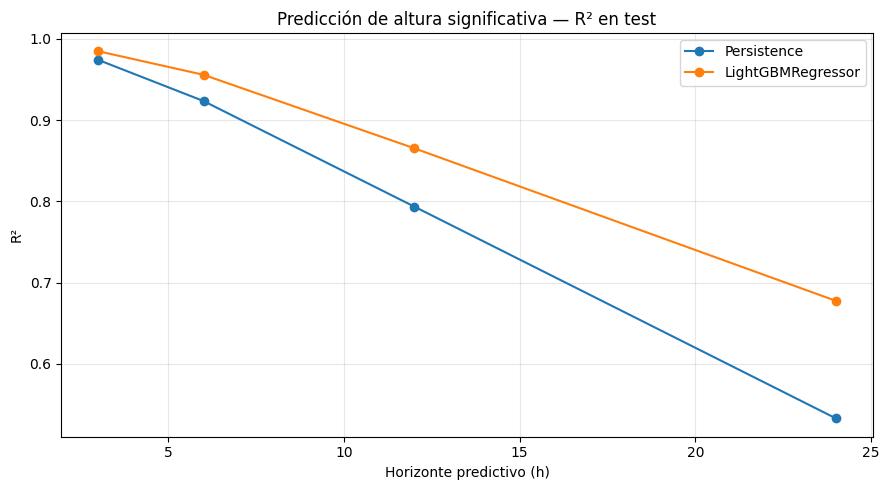

In [9]:
plot_lines(
    reg_test,
    metric="mae",
    title="Predicción de altura significativa — MAE en test",
    ylabel="MAE hs (m)",
    output_name="fig_01_regression_mae_test.png",
    models_order=["Persistence", "LightGBMRegressor"],
)

plot_lines(
    reg_test,
    metric="rmse",
    title="Predicción de altura significativa — RMSE en test",
    ylabel="RMSE hs (m)",
    output_name="fig_02_regression_rmse_test.png",
    models_order=["Persistence", "LightGBMRegressor"],
)

plot_lines(
    reg_test,
    metric="r2",
    title="Predicción de altura significativa — R² en test",
    ylabel="R²",
    output_name="fig_03_regression_r2_test.png",
    models_order=["Persistence", "LightGBMRegressor"],
)

## Celda 9 — Gráficos finales de riesgo

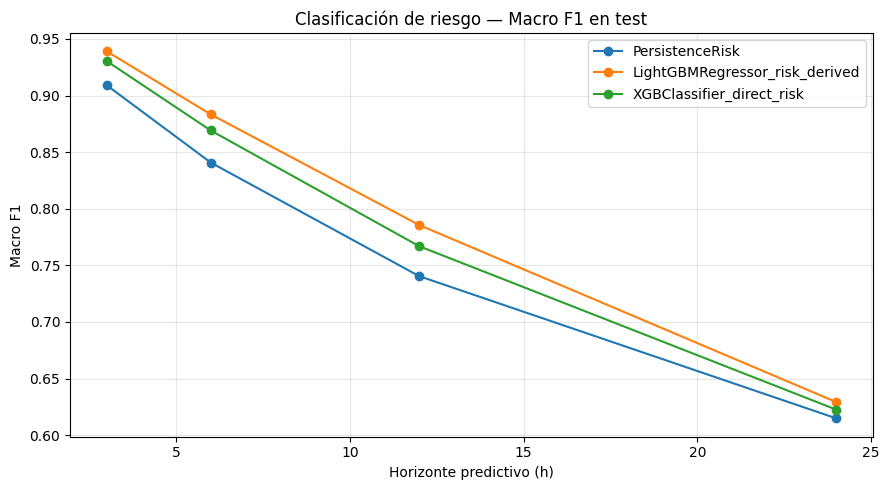

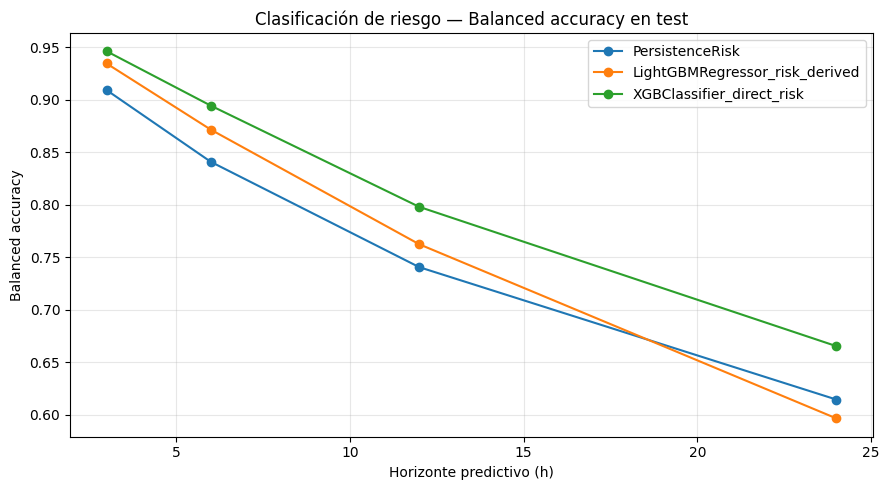

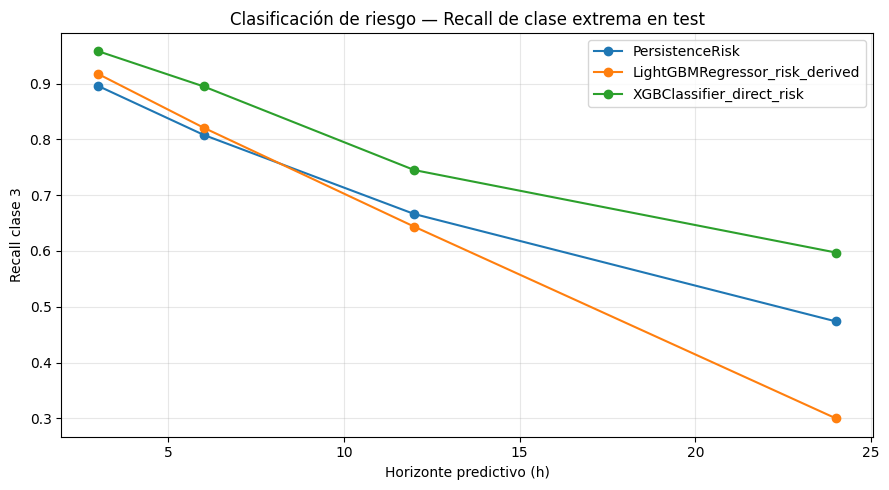

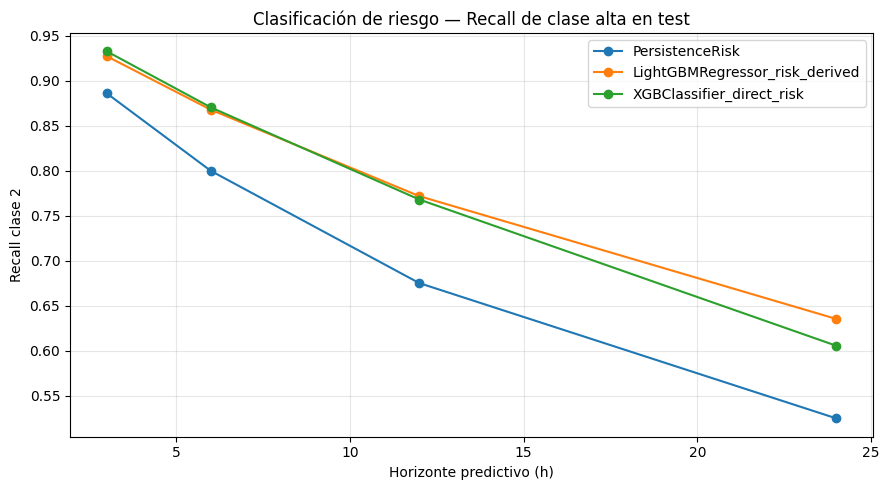

In [10]:
risk_models_order = [
    "PersistenceRisk",
    "LightGBMRegressor_risk_derived",
    "XGBClassifier_direct_risk",
]

plot_lines(
    risk_test,
    metric="macro_f1",
    title="Clasificación de riesgo — Macro F1 en test",
    ylabel="Macro F1",
    output_name="fig_04_risk_macro_f1_test.png",
    models_order=risk_models_order,
)

plot_lines(
    risk_test,
    metric="balanced_accuracy",
    title="Clasificación de riesgo — Balanced accuracy en test",
    ylabel="Balanced accuracy",
    output_name="fig_05_risk_balanced_accuracy_test.png",
    models_order=risk_models_order,
)

plot_lines(
    risk_test,
    metric="recall_class_3",
    title="Clasificación de riesgo — Recall de clase extrema en test",
    ylabel="Recall clase 3",
    output_name="fig_06_risk_recall_extreme_test.png",
    models_order=risk_models_order,
)

plot_lines(
    risk_test,
    metric="recall_class_2",
    title="Clasificación de riesgo — Recall de clase alta en test",
    ylabel="Recall clase 2",
    output_name="fig_07_risk_recall_high_test.png",
    models_order=risk_models_order,
)

## Celda 10 — Gráfico de score compuesto y modelo recomendado

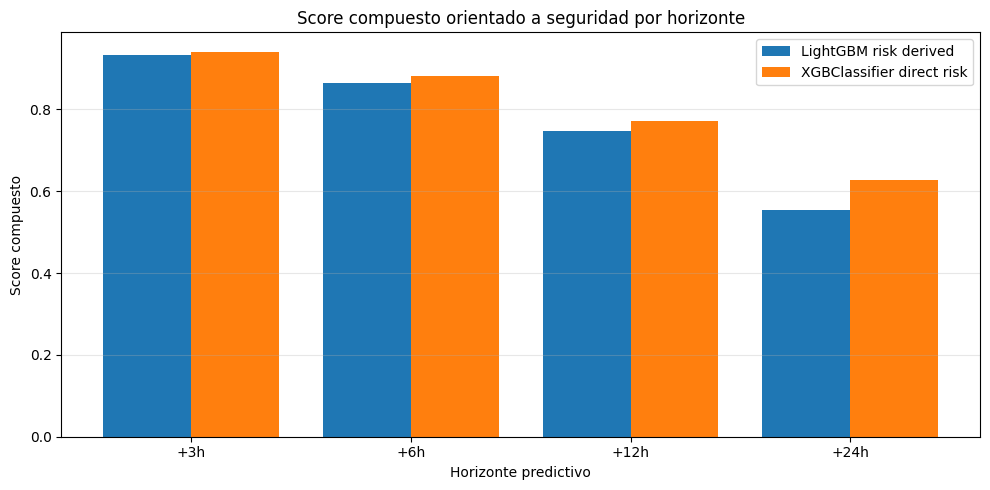

In [11]:
score_plot = final_model_decision[["horizon_hours", "score_lgbm", "score_xgb"]].copy()
score_long = score_plot.melt(
    id_vars="horizon_hours",
    value_vars=["score_lgbm", "score_xgb"],
    var_name="model",
    value_name="security_score",
)

score_long["model"] = score_long["model"].map(
    {
        "score_lgbm": "LightGBM risk derived",
        "score_xgb": "XGBClassifier direct risk",
    }
)

plot_grouped_bars(
    score_long,
    metric="security_score",
    title="Score compuesto orientado a seguridad por horizonte",
    ylabel="Score compuesto",
    output_name="fig_08_security_score_by_horizon.png",
    models_order=["LightGBM risk derived", "XGBClassifier direct risk"],
)

## Celda 11 — Importancias de variables resumidas

,feature,importance_gain,importance_split,horizon_hours,model_family,importance_weight
0,simar_hs,4.827723e+06,8518.0,3,LightGBMRegressor,NaN
1,simar_hs_lag_1h,7.429433e+05,7048.0,3,LightGBMRegressor,NaN
2,simar_hs_lag_3h,1.471515e+05,4192.0,3,LightGBMRegressor,NaN
3,simar_hs_roll_mean_6h,2.865419e+04,1307.0,3,LightGBMRegressor,NaN
4,simar_hs_lag_6h,5.503086e+03,2776.0,3,LightGBMRegressor,NaN
...,...,...,...,...,...,...
75,dayofyear_cos,1.166033e+02,NaN,24,XGBClassifier,8969.0
76,distance_to_10m_isobath,1.152353e+02,NaN,24,XGBClassifier,1227.0
77,zona_lat,9.642513e+01,NaN,24,XGBClassifier,2203.0
78,simar_wind_speed,9.099578e+01,NaN,24,XGBClassifier,1328.0


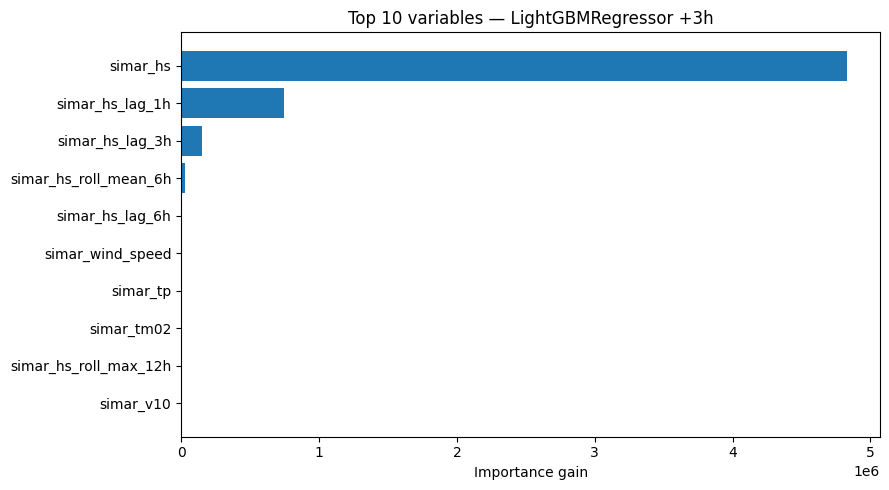

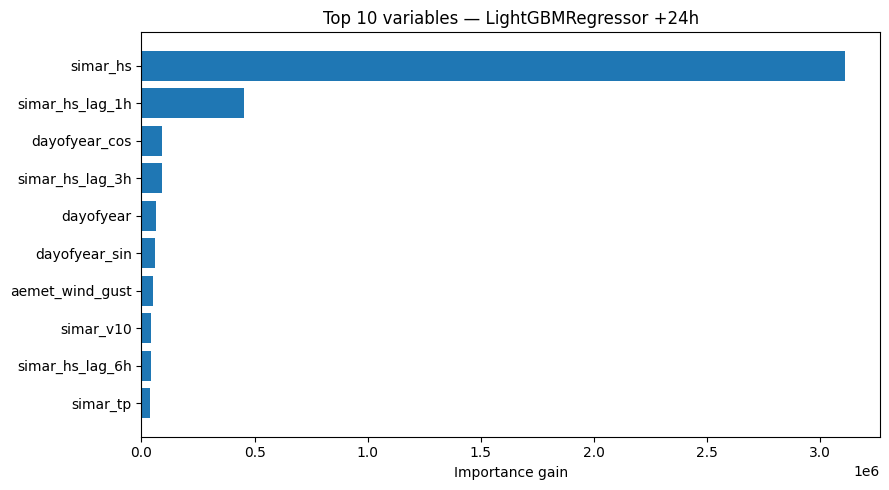

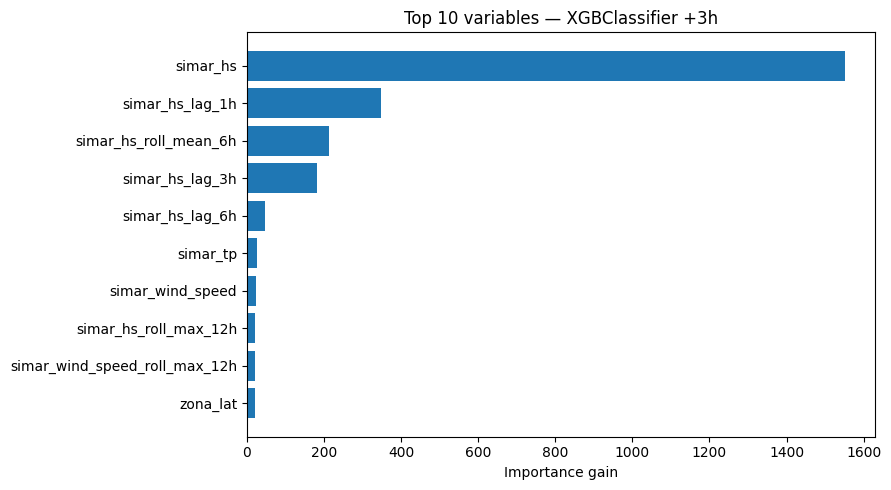

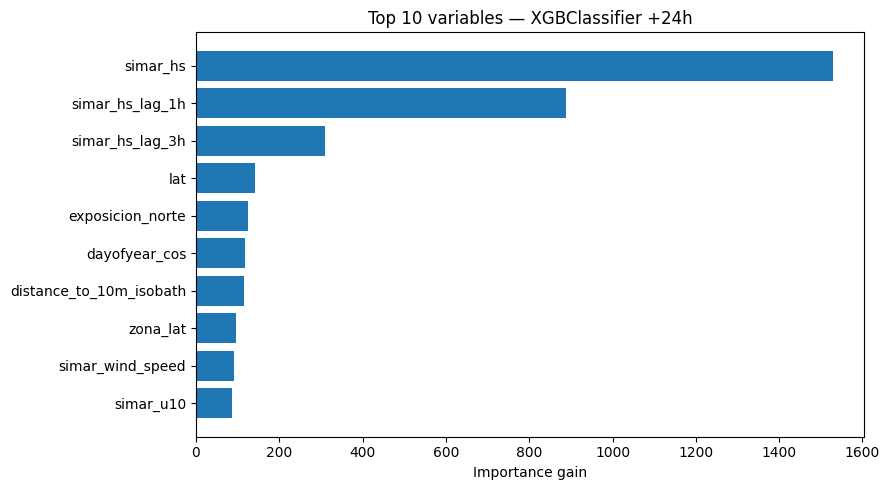

In [12]:
if not importance_top20.empty:
    # Guardar top 10 por modelo/horizonte para memoria.
    importance_top10 = (
        importance_top20
        .sort_values(["model_family", "horizon_hours", "importance_gain"], ascending=[True, True, False])
        .groupby(["model_family", "horizon_hours"])
        .head(10)
        .reset_index(drop=True)
    )

    importance_top10.to_csv(OUT_DIR / "table_04_top10_feature_importance_by_model_horizon.csv", index=False)

    display(importance_top10)

    # Gráficos compactos solo para +3h y +24h, que suelen ser los más interpretables.
    for model_family in importance_top10["model_family"].dropna().unique():
        for h in [3, 24]:
            plot_df = importance_top10[
                (importance_top10["model_family"] == model_family)
                & (importance_top10["horizon_hours"] == h)
            ].sort_values("importance_gain", ascending=True)

            if plot_df.empty:
                continue

            plt.figure(figsize=(9, 5))
            plt.barh(plot_df["feature"], plot_df["importance_gain"])
            plt.xlabel("Importance gain")
            plt.title(f"Top 10 variables — {model_family} +{h}h")
            plt.tight_layout()
            safe_name = str(model_family).replace(" ", "_").replace("/", "_")
            plt.savefig(OUT_DIR / f"fig_09_top_features_{safe_name}_h{h}.png", dpi=160)
            plt.show()
else:
    print("No hay tabla de importancias disponible.")

## Celda 12 — Tablas listas para memoria con formato redondeado

In [13]:
# Tabla de regresión formateada.
regression_doc = regression_final_summary.copy()

for c in regression_doc.columns:
    if c.endswith("_pct"):
        regression_doc[c] = regression_doc[c].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
    elif regression_doc[c].dtype.kind in "fc":
        regression_doc[c] = regression_doc[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

regression_doc.to_csv(OUT_DIR / "doc_table_regression_lightgbm_summary.csv", index=False)

# Tabla de riesgo formateada.
risk_doc = risk_final_summary.copy()

for c in risk_doc.columns:
    if risk_doc[c].dtype.kind in "fc":
        risk_doc[c] = risk_doc[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

risk_doc.to_csv(OUT_DIR / "doc_table_risk_comparison_summary.csv", index=False)

# Tabla de decisión formateada.
decision_doc = final_model_decision.copy()

for c in decision_doc.columns:
    if decision_doc[c].dtype.kind in "fc":
        decision_doc[c] = decision_doc[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

decision_doc.to_csv(OUT_DIR / "doc_table_final_model_decision.csv", index=False)

display(regression_doc)
display(risk_doc)
display(decision_doc)

,horizon_hours,model_selected_for_hs,mae_lightgbm,mae_persistence,mae_improvement_pct,rmse_lightgbm,rmse_persistence,rmse_improvement_pct,r2_lightgbm,r2_persistence,corr_lightgbm,corr_persistence,bias_lightgbm,bias_persistence
0,3,LightGBMRegressor,0.0626,0.0891,29.77%,0.0994,0.1300,23.57%,0.9850,0.9743,0.9925,0.9871,-0.0007,0.0003
1,6,LightGBMRegressor,0.1160,0.1558,25.58%,0.1702,0.2241,24.03%,0.9559,0.9236,0.9780,0.9618,0.0002,0.0007
2,12,LightGBMRegressor,0.2086,0.2558,18.46%,0.2974,0.3683,19.25%,0.8654,0.7935,0.9311,0.8968,0.0004,0.0015
3,24,LightGBMRegressor,0.3302,0.3878,14.86%,0.4603,0.5541,16.92%,0.6775,0.5327,0.8248,0.7664,-0.0093,0.0017


,horizon_hours,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,recall_class_2,recall_class_3,f1_class_2,f1_class_3,support_class_2,support_class_3
4,3,LightGBMRegressor_risk_derived,0.9448,0.9347,0.9392,0.9447,0.9272,0.9172,0.9265,0.9356,43696,13315
20,3,PersistenceRisk,0.9185,0.9093,0.9092,0.9185,0.8861,0.8958,0.8858,0.8952,43696,13315
12,3,XGBClassifier_direct_risk,0.9348,0.9463,0.9306,0.9351,0.9327,0.9581,0.9145,0.9302,43696,13315
5,6,LightGBMRegressor_risk_derived,0.8968,0.8716,0.8834,0.8966,0.8677,0.8210,0.8594,0.8631,43637,13297
21,6,PersistenceRisk,0.8587,0.8410,0.8408,0.8587,0.7998,0.8082,0.7993,0.8071,43637,13297
13,6,XGBClassifier_direct_risk,0.8783,0.8945,0.8691,0.8793,0.8703,0.8950,0.8377,0.8529,43637,13297
6,12,LightGBMRegressor_risk_derived,0.8149,0.7625,0.7856,0.8142,0.7717,0.6435,0.7470,0.7259,43534,13270
22,12,PersistenceRisk,0.7730,0.7406,0.7404,0.7731,0.6750,0.6662,0.6742,0.6646,43534,13270
14,12,XGBClassifier_direct_risk,0.7866,0.7981,0.7668,0.7895,0.7679,0.7450,0.7141,0.7008,43534,13270
7,24,LightGBMRegressor_risk_derived,0.7043,0.5966,0.6292,0.6984,0.6352,0.2999,0.5955,0.4224,43489,13261


,horizon_hours,hs_model,risk_model_recommended,score_lgbm,score_xgb,score_delta_xgb_minus_lgbm,macro_f1_lgbm,macro_f1_xgb,balanced_accuracy_lgbm,balanced_accuracy_xgb,recall_class_3_lgbm,recall_class_3_xgb,decision_reason
0,3,LightGBMRegressor,XGBClassifier_direct_risk,0.9316,0.9411,0.0095,0.9392,0.9306,0.9347,0.9463,0.9172,0.9581,Mejor score compuesto de seguridad.
1,6,LightGBMRegressor,XGBClassifier_direct_risk,0.8650,0.8821,0.0171,0.8834,0.8691,0.8716,0.8945,0.8210,0.8950,Mejor score compuesto de seguridad.
2,12,LightGBMRegressor,XGBClassifier_direct_risk,0.7481,0.7720,0.0239,0.7856,0.7668,0.7625,0.7981,0.6435,0.7450,Mejor score compuesto de seguridad.
3,24,LightGBMRegressor,XGBClassifier_direct_risk,0.5545,0.6278,0.0733,0.6292,0.6225,0.5966,0.6655,0.2999,0.5972,Mejor score compuesto de seguridad.


## Celda 13 — Texto automático para la memoria

In [14]:
# Extraer datos clave para texto.
best_reg_lines = []

for _, row in regression_final_summary.iterrows():
    best_reg_lines.append(
        f"- Horizonte +{int(row['horizon_hours'])}h: LightGBM obtuvo MAE={row['mae_lightgbm']:.4f} m "
        f"frente a {row['mae_persistence']:.4f} m de persistencia "
        f"({row['mae_improvement_pct']:.2f}% de mejora), con R²={row['r2_lightgbm']:.4f}."
    )

risk_lines = []

for _, row in final_model_decision.iterrows():
    h = int(row["horizon_hours"])
    recommended = row["risk_model_recommended"]

    risk_lines.append(
        f"- Horizonte +{h}h: el score compuesto favorece a `{recommended}` "
        f"(score XGB={row['score_xgb']:.4f}, score LightGBM={row['score_lgbm']:.4f}). "
        f"El recall de clase extrema fue {row['recall_class_3_xgb']:.4f} en XGBoost "
        f"frente a {row['recall_class_3_lgbm']:.4f} en LightGBM derivado."
    )

report_md = f"""
# Informe final de modelado — DeepWave Canarias

## Resumen ejecutivo

Se evaluaron tres enfoques principales:

1. **Persistencia**, como baseline físico sencillo.
2. **LightGBMRegressor**, para predecir la altura significativa de ola futura (`hs`) en horizontes de +3h, +6h, +12h y +24h.
3. **XGBClassifier**, para predecir directamente el nivel de riesgo marítimo futuro.

La comparación se realizó sobre el conjunto de test temporal, manteniendo zonas comunes entre train, validation y test.

## Resultados de regresión de altura significativa

El modelo **LightGBMRegressor** superó a la persistencia en todos los horizontes:

{chr(10).join(best_reg_lines)}

Por tanto, LightGBMRegressor queda seleccionado como modelo principal para la predicción continua de altura significativa de ola.

## Resultados de clasificación de riesgo marítimo

Para el riesgo marítimo se compararon:

- riesgo derivado desde la predicción de `hs` de LightGBMRegressor;
- clasificación directa mediante XGBClassifier;
- persistencia de riesgo como baseline.

La métrica de decisión principal combinó macro F1, balanced accuracy y recall de clases peligrosas, dando más peso al recall de la clase extrema.

{chr(10).join(risk_lines)}

La conclusión es que **XGBClassifier es preferible para riesgo operativo** cuando se prioriza la detección de eventos altos y extremos, especialmente en horizontes largos.

## Decisión final propuesta

| Tarea | Modelo recomendado |
|---|---|
| Predicción de altura significativa de ola | LightGBMRegressor |
| Clasificación de riesgo marítimo | XGBClassifier |
| Baseline de comparación | Persistencia |

## Interpretación

LightGBMRegressor mostró mejor comportamiento global para la predicción continua de oleaje, con mejoras claras frente a persistencia en MAE, RMSE y R². Sin embargo, XGBClassifier mostró mejor capacidad para detectar clases peligrosas, especialmente la clase extrema, aunque en algunos horizontes sacrifica parte de la accuracy global.

Desde el punto de vista de un sistema de alerta marítima, resulta preferible priorizar la detección de riesgo alto/extremo frente a maximizar únicamente la accuracy general.
"""

save_markdown(report_md, OUT_DIR / "final_modeling_report_summary.md")

print(report_md)


# Informe final de modelado — DeepWave Canarias

## Resumen ejecutivo

Se evaluaron tres enfoques principales:

1. **Persistencia**, como baseline físico sencillo.
2. **LightGBMRegressor**, para predecir la altura significativa de ola futura (`hs`) en horizontes de +3h, +6h, +12h y +24h.
3. **XGBClassifier**, para predecir directamente el nivel de riesgo marítimo futuro.

La comparación se realizó sobre el conjunto de test temporal, manteniendo zonas comunes entre train, validation y test.

## Resultados de regresión de altura significativa

El modelo **LightGBMRegressor** superó a la persistencia en todos los horizontes:

- Horizonte +3h: LightGBM obtuvo MAE=0.0626 m frente a 0.0891 m de persistencia (29.77% de mejora), con R²=0.9850.
- Horizonte +6h: LightGBM obtuvo MAE=0.1160 m frente a 0.1558 m de persistencia (25.58% de mejora), con R²=0.9559.
- Horizonte +12h: LightGBM obtuvo MAE=0.2086 m frente a 0.2558 m de persistencia (18.46% de mejora), con R²=0.8654.
- Horizonte +24h: Ligh

## Celda 14 — Generar resumen JSON para uso posterior

In [15]:
final_summary_json = {
    "project": "DeepWave Canarias",
    "stage": "modeling_final_report",
    "models_evaluated": [
        "Persistence",
        "LightGBMRegressor",
        "XGBClassifier",
    ],
    "selected_models": {
        "wave_height_regression": "LightGBMRegressor",
        "risk_classification": "XGBClassifier_direct_risk",
        "baseline": "Persistence",
    },
    "horizons_hours": HORIZONS_HOURS,
    "regression_summary": regression_final_summary.to_dict(orient="records"),
    "risk_summary": risk_final_summary.to_dict(orient="records"),
    "final_model_decision": final_model_decision.to_dict(orient="records"),
    "recommendation_summary": recommendation.to_dict(orient="records"),
    "outputs_dir": str(OUT_DIR),
}

save_json(final_summary_json, OUT_DIR / "final_modeling_report_summary.json")

print("JSON guardado:")
print(OUT_DIR / "final_modeling_report_summary.json")

JSON guardado:
/content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/final_modeling_report_summary.json


## Celda 15 — Índice de archivos generados

In [16]:
generated_files = []

for p in sorted(OUT_DIR.glob("*")):
    generated_files.append(
        {
            "filename": p.name,
            "path": str(p),
            "suffix": p.suffix,
            "size_kb": round(p.stat().st_size / 1024, 2),
        }
    )

generated_files_df = pd.DataFrame(generated_files)
generated_files_df.to_csv(OUT_DIR / "generated_files_index.csv", index=False)

display(generated_files_df)

,filename,path,suffix,size_kb
0,doc_table_final_model_decision.csv,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.csv,0.78
1,doc_table_regression_lightgbm_summary.csv,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.csv,0.63
2,doc_table_risk_comparison_summary.csv,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.csv,1.26
3,fig_01_regression_mae_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,75.87
4,fig_02_regression_rmse_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,72.39
5,fig_03_regression_r2_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,73.02
6,fig_04_risk_macro_f1_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,109.88
7,fig_05_risk_balanced_accuracy_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,112.05
8,fig_06_risk_recall_extreme_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,98.59
9,fig_07_risk_recall_high_test.png,/content/drive/MyDrive/AI Projects/DeepWave Ca...,.png,111.31


## Celda 16 — Validación final

In [17]:
required_outputs = [
    OUT_DIR / "table_01_regression_lightgbm_summary.csv",
    OUT_DIR / "table_02_risk_model_comparison_test.csv",
    OUT_DIR / "table_03_final_model_decision_by_horizon.csv",
    OUT_DIR / "doc_table_regression_lightgbm_summary.csv",
    OUT_DIR / "doc_table_risk_comparison_summary.csv",
    OUT_DIR / "doc_table_final_model_decision.csv",
    OUT_DIR / "final_modeling_report_summary.md",
    OUT_DIR / "final_modeling_report_summary.json",
    OUT_DIR / "generated_files_index.csv",
    OUT_DIR / "fig_01_regression_mae_test.png",
    OUT_DIR / "fig_04_risk_macro_f1_test.png",
    OUT_DIR / "fig_06_risk_recall_extreme_test.png",
]

missing = [str(p) for p in required_outputs if not p.exists()]

if missing:
    raise FileNotFoundError("Faltan salidas esperadas: " + json.dumps(missing, indent=2))

if regression_final_summary.empty:
    raise ValueError("regression_final_summary está vacío.")

if risk_final_summary.empty:
    raise ValueError("risk_final_summary está vacío.")

if final_model_decision.empty:
    raise ValueError("final_model_decision está vacío.")

print("Salidas principales:")
for p in required_outputs:
    print("-", p)

print("\n✅ Informe final de modelado generado correctamente.")

Salidas principales:
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/table_01_regression_lightgbm_summary.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/table_02_risk_model_comparison_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/table_03_final_model_decision_by_horizon.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/doc_table_regression_lightgbm_summary.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/doc_table_risk_comparison_summary.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/doc_table_final_model_decision.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/final_modeling_report_summary.md
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/final_report/final_mod

## Resultado esperado

Al final debe aparecer:

```text
✅ Informe final de modelado generado correctamente.
```

Carpeta de salida:

```text
gold/model_results/final_report/
```

Archivos más importantes para documentar:

```text
final_modeling_report_summary.md
table_01_regression_lightgbm_summary.csv
table_02_risk_model_comparison_test.csv
table_03_final_model_decision_by_horizon.csv
doc_table_regression_lightgbm_summary.csv
doc_table_risk_comparison_summary.csv
doc_table_final_model_decision.csv
fig_01_regression_mae_test.png
fig_04_risk_macro_f1_test.png
fig_06_risk_recall_extreme_test.png
fig_08_security_score_by_horizon.png
```

Conclusión esperada:

```text
- LightGBMRegressor como modelo principal para altura significativa de ola.
- XGBClassifier como modelo recomendado para clasificación directa de riesgo marítimo.
```

Siguiente paso posible:

```text
13_model_training_tcn.ipynb
```

para comparar con un modelo temporal profundo, o pasar a:

```text
15_gold_operational_forecast_features.ipynb
```

si se quiere preparar inferencia operativa sobre las 561 playas.